In [45]:
import pandas as pd

df = pd.read_csv('/content/Employee.csv')

df.head(5)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [46]:
df.shape

(4653, 9)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


No Null values.

Duplicates can not be eliminated as there is no unique identifier for the records.

In [48]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


No numeric values which are indicative of a logical missing values.

In [49]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col}: {df[col].value_counts()}")

Education: Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64
City: City
Bangalore    2228
Pune         1268
New Delhi    1157
Name: count, dtype: int64
Gender: Gender
Male      2778
Female    1875
Name: count, dtype: int64
EverBenched: EverBenched
No     4175
Yes     478
Name: count, dtype: int64


No categorical logical missing values.

In [50]:
df['LeaveOrNot'].value_counts(normalize=True) * 100

,proportion
LeaveOrNot,
0,65.613583
1,34.386417


Class imbalance is not a concern.

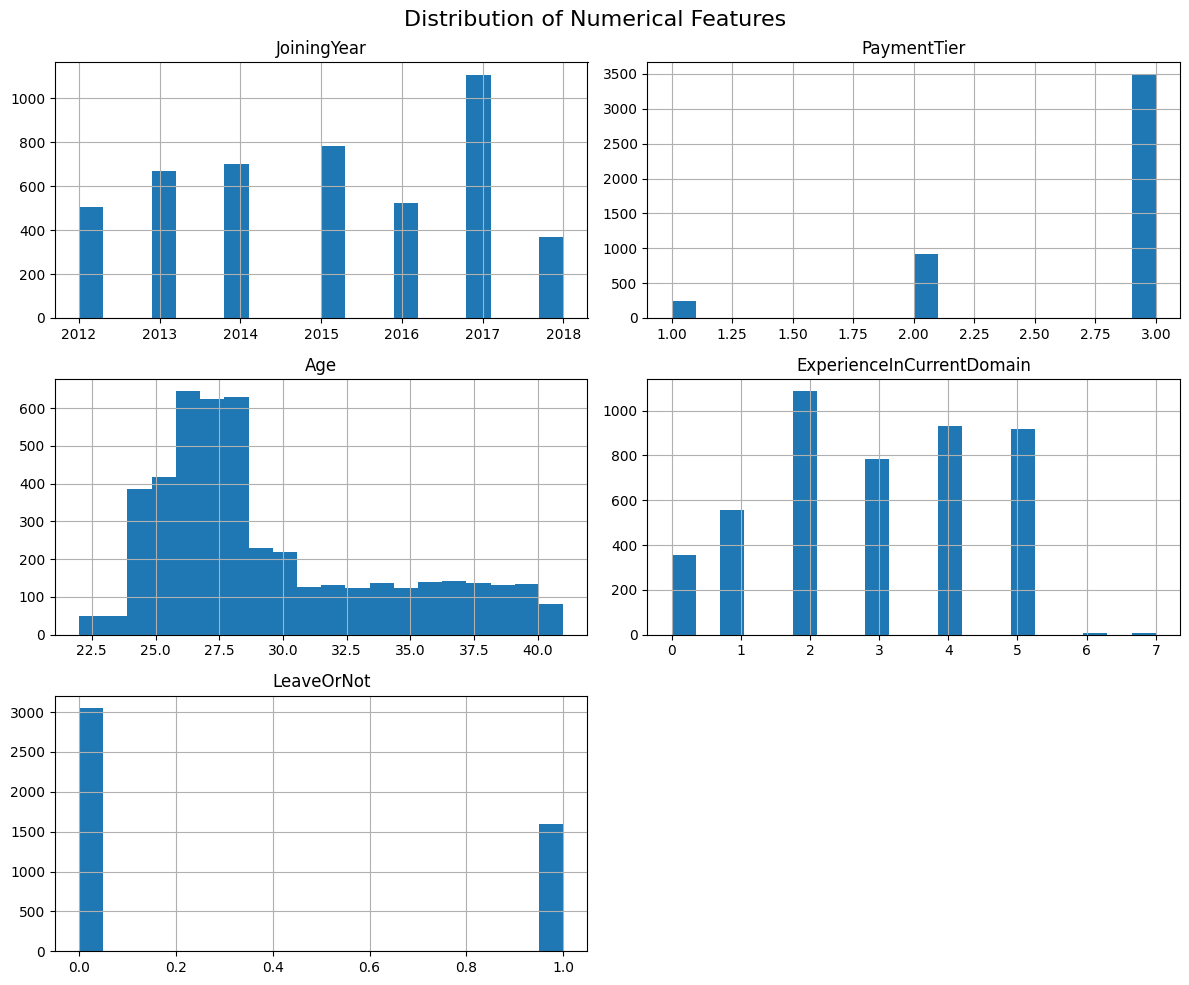

In [51]:
import matplotlib.pyplot as plt

# Numerical feature distributions (target shown as well)
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

Can treat payment tier as ordinal categorical variable.

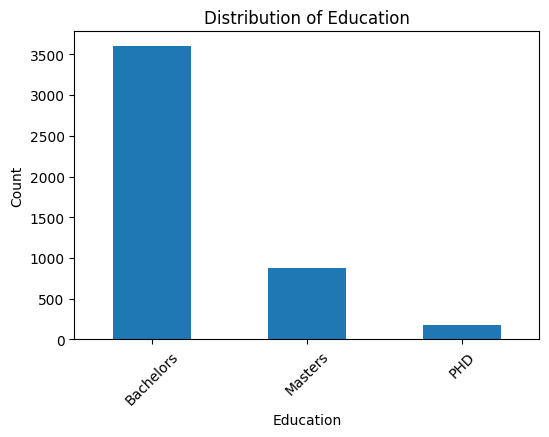

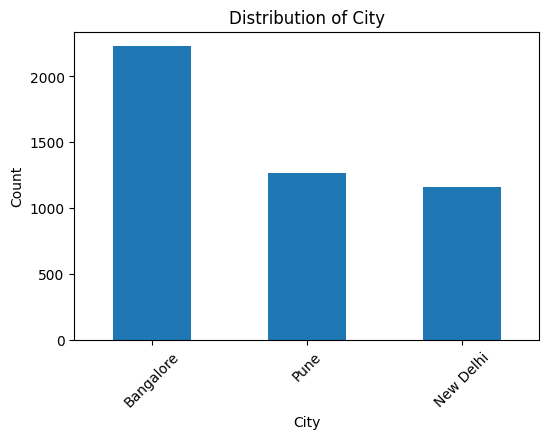

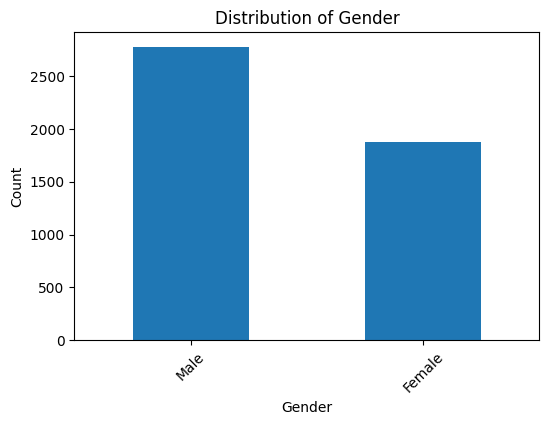

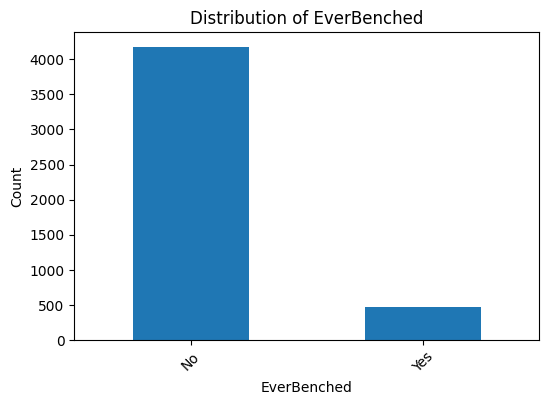

In [52]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Categorical feature distributions
for col in categorical_cols:
    df[col].value_counts().plot(kind='bar', figsize=(6, 4))
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

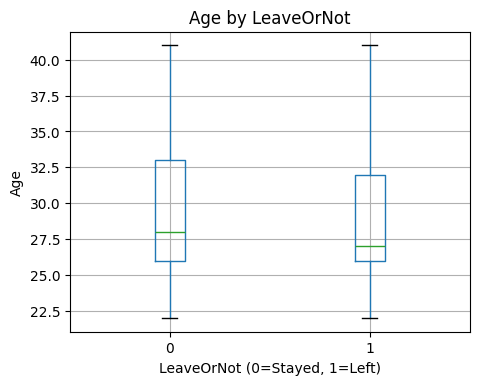

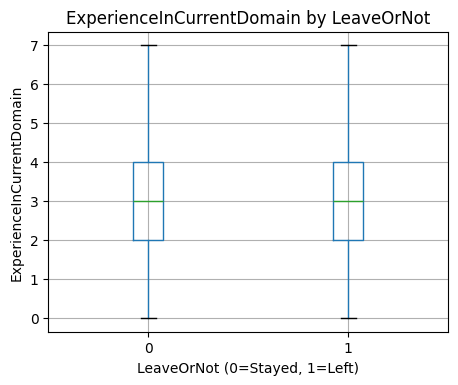

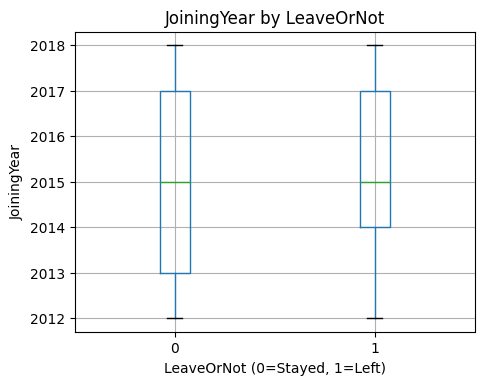

In [53]:
num_cols = ['Age', 'ExperienceInCurrentDomain', 'JoiningYear']

for col in num_cols:
        df.boxplot(column=col, by='LeaveOrNot', figsize=(5, 4))
        plt.title(f'{col} by LeaveOrNot')
        plt.suptitle('')
        plt.xlabel('LeaveOrNot (0=Stayed, 1=Left)')
        plt.ylabel(col)
        plt.show()

H0: mean age of employees who stayed = mean age of employees who left

H1: mean age of employees who stayed != mean age of employees who left

In [54]:
from scipy.stats import ttest_ind

age_left = df[df['LeaveOrNot'] == 1]['Age']
age_stayed = df[df['LeaveOrNot'] == 0]['Age']

t_stat, p_value = ttest_ind(age_left, age_stayed, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_value)
print("mean age (left):", age_left.mean())
print("mean age (stayed):", age_stayed.mean())

t-statistic: -3.491261554959713
p-value: 0.0004852123420648862
mean age (left): 29.0525
mean age (stayed): 29.571896495250574


Student-t test employed with equal variance. There is no statistical difference between this and Welch's. See Levene's.

In [55]:
from scipy.stats import levene

stat, p = levene(age_left, age_stayed)
print("Levene’s test p-value:", p)

Levene’s test p-value: 0.18218615302628788


No statistical difference in variances measured between age of stayed versus left. P value > .05.

In [56]:
import numpy as np

age_left = df[df['LeaveOrNot'] == 1]['Age']
age_stayed = df[df['LeaveOrNot'] == 0]['Age']

n1, n2 = len(age_left), len(age_stayed)
s1, s2 = age_left.std(ddof=1), age_stayed.std(ddof=1)
m1, m2 = age_left.mean(), age_stayed.mean()

s_pooled = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))

cohens_d = (m1 - m2) / s_pooled
print("Cohen's d magnitude:", abs(cohens_d))

Cohen's d magnitude: 0.10775204440349131


P-Value far below .05 and it is reasonable to reject the null hypothesis.

However, this may be inconsequential due to about a half year gap between the means and Cohen's d test suggests as well. Likely there is no actionable use of this information from a business standpoint.

Age could be considered as a control variable for other tests.

Payment tier is ordinal categorical variable not numerical.

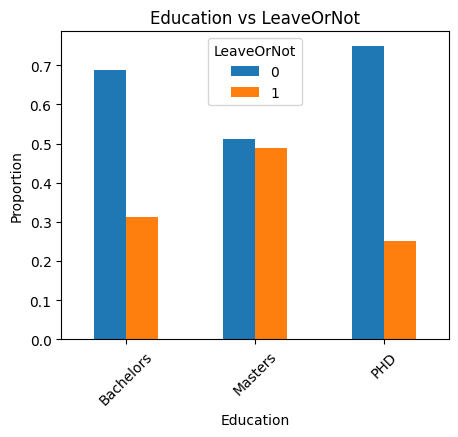

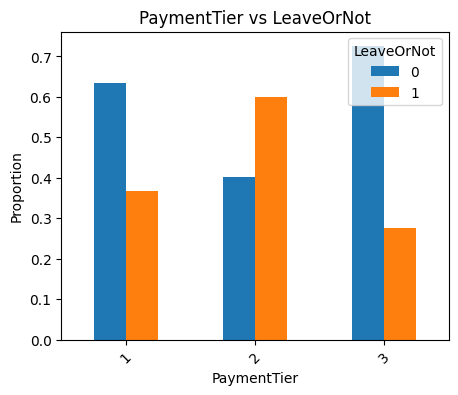

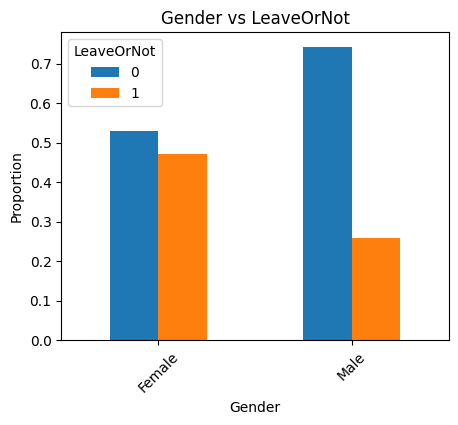

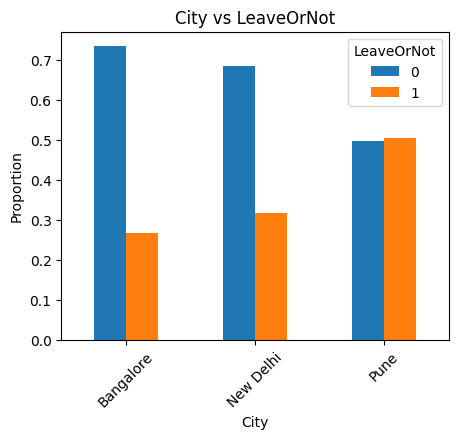

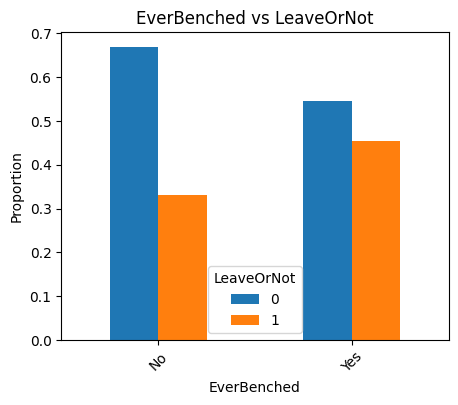

In [57]:
cat_cols = ['Education', 'PaymentTier', 'Gender', 'City', 'EverBenched']

for col in cat_cols:
        pd.crosstab(df[col], df['LeaveOrNot'], normalize='index').plot(
            kind='bar', stacked=False, figsize=(5, 4))
        plt.title(f'{col} vs LeaveOrNot')
        plt.ylabel('Proportion')
        plt.legend(title='LeaveOrNot')
        plt.xticks(rotation=45)
        plt.show()

In [58]:
from scipy.stats import chi2_contingency

def chi_squared_test(df, feature, target='LeaveOrNot'):
    table = pd.crosstab(df[feature], df[target])

    chi2, p, dof, expected = chi2_contingency(table)

    # Cramer's V
    n = table.values.sum()
    r, c = table.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

    print(table)
    print(f"Chi2 = {chi2:.3f}, p-value = {p:.3f}, dof = {dof}")
    print(f"Cramér's V = {cramers_v:.3f}")

    if p < 0.05:
        print("Conclusion: Reject H₀ → Significant association with LeaveOrNot.")
    else:
        print("Conclusion: Fail to reject H₀ → No significant association.")

In [59]:
for feature in cat_cols:
    chi_squared_test(df, feature)
    print()

LeaveOrNot     0     1
Education             
Bachelors   2472  1129
Masters      447   426
PHD          134    45
Chi2 = 101.830, p-value = 0.000, dof = 2
Cramér's V = 0.148
Conclusion: Reject H₀ → Significant association with LeaveOrNot.

LeaveOrNot      0    1
PaymentTier           
1             154   89
2             368  550
3            2531  961
Chi2 = 338.631, p-value = 0.000, dof = 2
Cramér's V = 0.270
Conclusion: Reject H₀ → Significant association with LeaveOrNot.

LeaveOrNot     0    1
Gender               
Female       991  884
Male        2062  716
Chi2 = 225.695, p-value = 0.000, dof = 1
Cramér's V = 0.220
Conclusion: Reject H₀ → Significant association with LeaveOrNot.

LeaveOrNot     0    1
City                 
Bangalore   1633  595
New Delhi    791  366
Pune         629  639
Chi2 = 206.159, p-value = 0.000, dof = 2
Cramér's V = 0.210
Conclusion: Reject H₀ → Significant association with LeaveOrNot.

LeaveOrNot      0     1
EverBenched            
No           2792  1

While differences in proportions amongst feature versus target are statistically significant the effect size is limited in almost every case. There is always a negligible to weak size effect. No one feature should be considered when predicting leave or not. Multivariate modeling is recommended.

Furthermore, when conducting an A/B test comparing employees who were benched versus those who were not (to see if this is a useful practice in terms of use of company resources), there was no statistically significant evidence to suggest that either group was retained at a higher or lower rate.

Is education or compensation more likely to lead to retention?

In [60]:
from scipy.stats import f_oneway
# Education influence on years in domain
groups_edu = [
    group['ExperienceInCurrentDomain'].values
    for _, group in df.groupby('Education')
]

f_stat_edu, p_value_edu = f_oneway(*groups_edu)

print("ANOVA: Experience by Education")
print(f"F-statistic: {f_stat_edu:.3f}")
print(f"P-value: {p_value_edu:.4f}")

ANOVA: Experience by Education
F-statistic: 0.101
P-value: 0.9041


Since p > .05(alpha) we fail to reject null hypothesis.
We fail to reject H0: mean years in domain for bachelor's, master's and p.h.d. are equal.

In [61]:
# Payment tier influence on years in domain
groups_tier = [
    group['ExperienceInCurrentDomain'].values
    for _, group in df.groupby('PaymentTier')
]

f_stat_tier, p_value_tier = f_oneway(*groups_tier)

print("ANOVA: Experience by PaymentTier")
print(f"F-statistic: {f_stat_tier:.3f}")
print(f"P-value: {p_value_tier:.4f}")

ANOVA: Experience by PaymentTier
F-statistic: 1.139
P-value: 0.3203


Since p > .05(alpha) we fail to reject null hypothesis. We fail to reject H0: mean years in domain for all payment tiers are equal.

In [62]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Anova
model = ols('ExperienceInCurrentDomain ~ C(Education)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Eta^2
eta_squared = anova_table['sum_sq']['C(Education)'] / anova_table['sum_sq'].sum()
print("Eta Squared (η²) - (Education):", eta_squared)

Eta Squared (η²) - (Education): 4.3346176540837573e-05


In [63]:
# Anova
model_tier = ols('ExperienceInCurrentDomain ~ C(PaymentTier)', data=df).fit()
anova_table_tier = sm.stats.anova_lm(model_tier, typ=2)

# Eta^2
eta_squared_tier = (
    anova_table_tier['sum_sq']['C(PaymentTier)'] /
    anova_table_tier['sum_sq'].sum()
)

print("Eta Squared (η²) - (PaymentTier):", eta_squared_tier)

Eta Squared (η²) - (PaymentTier): 0.0004895085492838536


Payment Tier and Education are both statistically insignificant for difference in years in domain and effect size is negligible.